# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


In [149]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

In [150]:
path = "appletree.jpg"

First we load the image

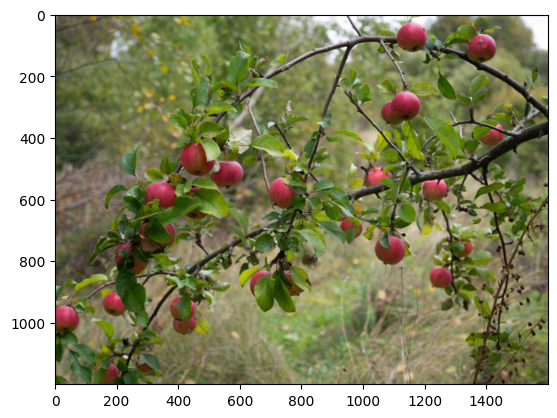

In [151]:
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
plt.imshow(image)

## Segmenting the apples form the tree and counting them

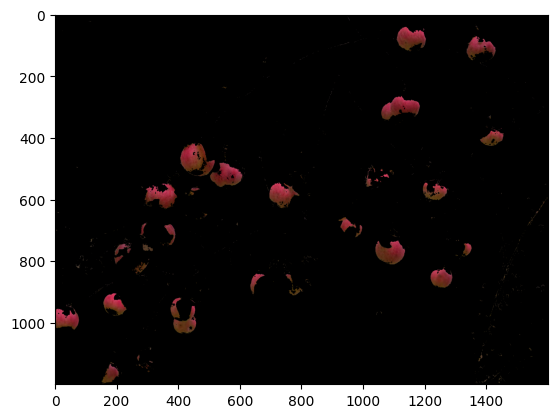

In [152]:
# Create upper and lower bounds for the red color of the apples
upper_red= np.array([255, 70, 130], dtype = "uint8")
lower_red = np.array([80, 20, 10], dtype = "uint8")

# Create mask for the apples, tweak the rgb value bounds
mask = cv2.inRange(image, lower_red, upper_red)

output = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(output)

Convert rgb to greyscale to be able to threshold

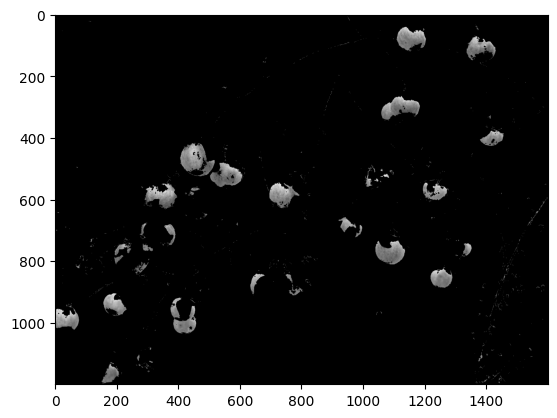

In [153]:
gray = cv2.cvtColor(output, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

Then threshold greyscale:

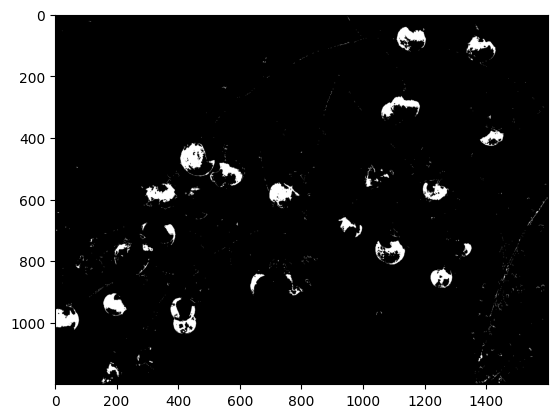

In [154]:
threshold = 60
threshold_value = 255

thresh = cv2.threshold(gray, threshold, threshold_value, cv2.THRESH_BINARY)[1]
plt.imshow(thresh, cmap='gray')

Threshold contains a very scattered image so we apply first erosion and then dilation to only let bigger regions survive (regions marking an apple)

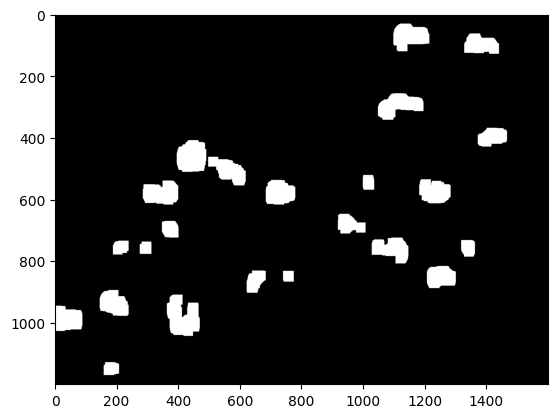

In [155]:
eroded_thres = cv2.erode(thresh, None, iterations=3) # first erosion
dilated_thres = cv2.dilate(eroded_thres, None, iterations=15) # then dilation
plt.imshow(dilated_thres, cmap='gray')

Use this mask for the apples to find contours

In [156]:
cnts = cv2.findContours(dilated_thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts) # grab contours

Count contours and overlay with original image to compare

Apples counted:  23
Actual apples:  26


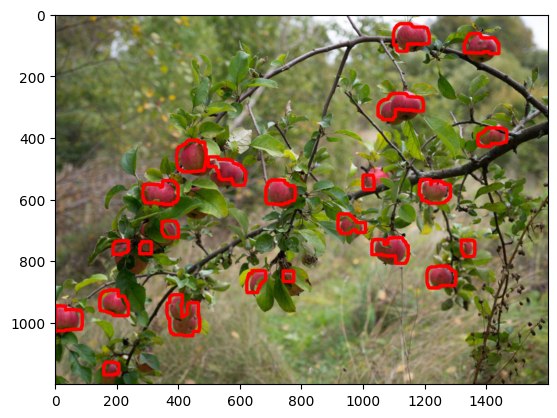

In [157]:
comparison_image = image.copy()

for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(comparison_image, [c], -1, (255, 0, 0), 10)
    
print("Apples counted: ", len(cnts))
print("Actual apples: ", 26)
plt.imshow(comparison_image)

## Changing the color of an apple

Strategy: Get a clean segmentation of an apple and then change the color using masking.

Using using the same segmentation as before and then choosing the biggest apple via the biggest contour area found.

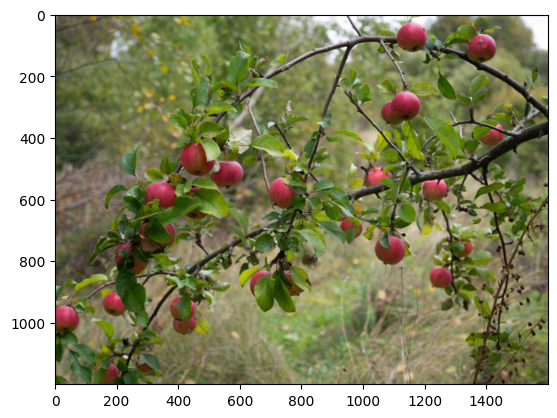

In [158]:
plt.imshow(image)

Starting from the threshold picture applying a thinner dilation

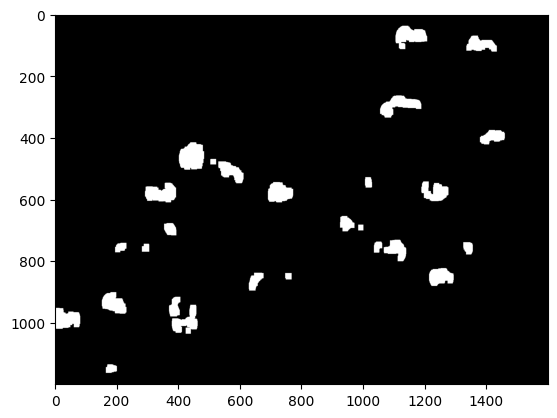

In [159]:
eroded_thres = cv2.erode(thresh, None, iterations=3) # first erosion
dilated_thres = cv2.dilate(eroded_thres, None, iterations=8) # then dilation
plt.imshow(dilated_thres, cmap='gray')

In [ ]:
cnts = cv2.findContours(dilated_thres.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts) # grab new smaller contours

In [ ]:
# By area (e.g. biggest apple)
areas = [cv2.contourArea(c) for c in cnts]
target_idx = np.argmax(areas)  # e.g. the largest one
target_contour = cnts[target_idx]

target_idx

np.int64(22)

With the target contour, now draw the mask to draw exactly this and only this apple

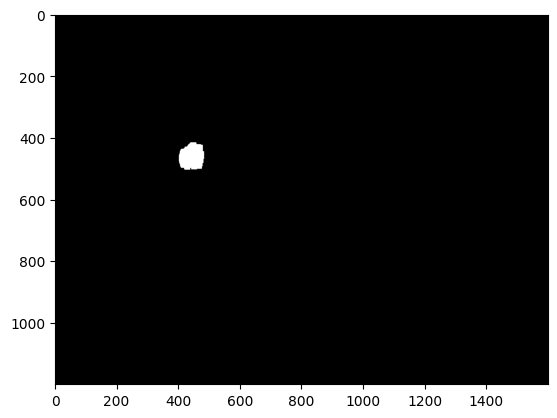

In [176]:
single_mask = np.zeros(image.shape[:2], dtype="uint8") # create a black canvas
cv2.drawContours(single_mask, [target_contour], -1, 255, thickness=-1)  # -1 = filled out, instead of just a line

plt.imshow(single_mask, cmap='gray') # show the mask

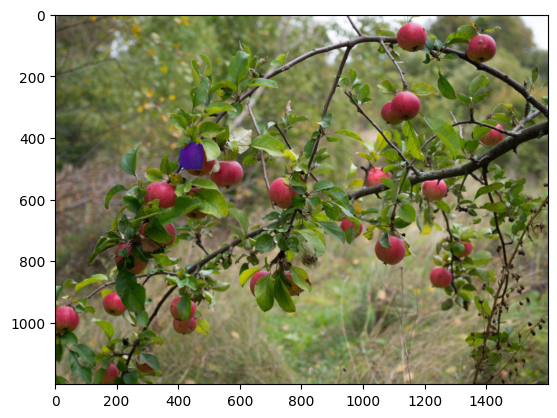

In [177]:
output = image.copy()
#output[single_mask == 255] = [0, 255, 0]  # e.g. recolor to green
overlay = image.copy()
overlay[single_mask == 255] = [0, 0, 200]
output = cv2.addWeighted(overlay, 0.5, image, 0.5, 0)
plt.imshow(output)